# 📱 Mobile Price Range Prediction
## Machine Learning Pipeline — Logistic Regression Classifier

**Objective:** Predict the price range category of a mobile phone based on its hardware and connectivity specifications.

**Target Variable:** `price_range` — a 4-class label:

| Class | Description |
|-------|-------------|
| 0 | Low cost |
| 1 | Medium cost |
| 2 | High cost |
| 3 | Very high cost |

**Dataset:** `mobile_train.csv` (2,000 samples, 21 features) | `mobile_test.csv` (unlabelled inference set)

**Pipeline Stages:** Data Loading → EDA → Quality Checks → Outlier Removal → Feature Engineering → Train/Test Split → Scaling → Model Training → Evaluation → Inference → Feature Importance

---

In [163]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os


## 1. Import Libraries

Import all required libraries for data manipulation, visualisation, and machine learning.

---

## 2. Data Loading

Load the training dataset from CSV into a Pandas DataFrame. The dataset contains **2,000 mobile phone records** across **21 features** with a balanced target class distribution of 500 samples per price category.

In [164]:
df = pd.read_csv('mobile_train.csv')

---

## 3. Exploratory Data Analysis (EDA)

Inspect the structure of the dataset: preview rows, review statistics, list columns, check class balance, and analyse feature correlations with the target variable. A **correlation heatmap** is generated to visualise pairwise relationships between all features.

In [165]:
df.head()

,battery_power,blue,clock_speed,dual_sim,fc,four_g,int_memory,m_dep,mobile_wt,n_cores,...,px_height,px_width,ram,sc_h,sc_w,talk_time,three_g,touch_screen,wifi,price_range
0,842,0,2.2,0,1,0,7,0.6,188,2,...,20,756,2549,9,7,19,0,0,1,1
1,1021,1,0.5,1,0,1,53,0.7,136,3,...,905,1988,2631,17,3,7,1,1,0,2
2,563,1,0.5,1,2,1,41,0.9,145,5,...,1263,1716,2603,11,2,9,1,1,0,2
3,615,1,2.5,0,0,0,10,0.8,131,6,...,1216,1786,2769,16,8,11,1,0,0,2
4,1821,1,1.2,0,13,1,44,0.6,141,2,...,1208,1212,1411,8,2,15,1,1,0,1


In [166]:
df.tail()

,battery_power,blue,clock_speed,dual_sim,fc,four_g,int_memory,m_dep,mobile_wt,n_cores,...,px_height,px_width,ram,sc_h,sc_w,talk_time,three_g,touch_screen,wifi,price_range
1995,794,1,0.5,1,0,1,2,0.8,106,6,...,1222,1890,668,13,4,19,1,1,0,0
1996,1965,1,2.6,1,0,0,39,0.2,187,4,...,915,1965,2032,11,10,16,1,1,1,2
1997,1911,0,0.9,1,1,1,36,0.7,108,8,...,868,1632,3057,9,1,5,1,1,0,3
1998,1512,0,0.9,0,4,1,46,0.1,145,5,...,336,670,869,18,10,19,1,1,1,0
1999,510,1,2.0,1,5,1,45,0.9,168,6,...,483,754,3919,19,4,2,1,1,1,3


In [167]:
df.describe()

,battery_power,blue,clock_speed,dual_sim,fc,four_g,int_memory,m_dep,mobile_wt,n_cores,...,px_height,px_width,ram,sc_h,sc_w,talk_time,three_g,touch_screen,wifi,price_range
count,2000.000000,2000.0000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,...,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000
mean,1238.518500,0.4950,1.522250,0.509500,4.309500,0.521500,32.046500,0.501750,140.249000,4.520500,...,645.108000,1251.515500,2124.213000,12.306500,5.767000,11.011000,0.761500,0.503000,0.507000,1.500000
std,439.418206,0.5001,0.816004,0.500035,4.341444,0.499662,18.145715,0.288416,35.399655,2.287837,...,443.780811,432.199447,1084.732044,4.213245,4.356398,5.463955,0.426273,0.500116,0.500076,1.118314
min,501.000000,0.0000,0.500000,0.000000,0.000000,0.000000,2.000000,0.100000,80.000000,1.000000,...,0.000000,500.000000,256.000000,5.000000,0.000000,2.000000,0.000000,0.000000,0.000000,0.000000
25%,851.750000,0.0000,0.700000,0.000000,1.000000,0.000000,16.000000,0.200000,109.000000,3.000000,...,282.750000,874.750000,1207.500000,9.000000,2.000000,6.000000,1.000000,0.000000,0.000000,0.750000
50%,1226.000000,0.0000,1.500000,1.000000,3.000000,1.000000,32.000000,0.500000,141.000000,4.000000,...,564.000000,1247.000000,2146.500000,12.000000,5.000000,11.000000,1.000000,1.000000,1.000000,1.500000
75%,1615.250000,1.0000,2.200000,1.000000,7.000000,1.000000,48.000000,0.800000,170.000000,7.000000,...,947.250000,1633.000000,3064.500000,16.000000,9.000000,16.000000,1.000000,1.000000,1.000000,2.250000
max,1998.000000,1.0000,3.000000,1.000000,19.000000,1.000000,64.000000,1.000000,200.000000,8.000000,...,1960.000000,1998.000000,3998.000000,19.000000,18.000000,20.000000,1.000000,1.000000,1.000000,3.000000


In [168]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   battery_power  2000 non-null   int64  
 1   blue           2000 non-null   int64  
 2   clock_speed    2000 non-null   float64
 3   dual_sim       2000 non-null   int64  
 4   fc             2000 non-null   int64  
 5   four_g         2000 non-null   int64  
 6   int_memory     2000 non-null   int64  
 7   m_dep          2000 non-null   float64
 8   mobile_wt      2000 non-null   int64  
 9   n_cores        2000 non-null   int64  
 10  pc             2000 non-null   int64  
 11  px_height      2000 non-null   int64  
 12  px_width       2000 non-null   int64  
 13  ram            2000 non-null   int64  
 14  sc_h           2000 non-null   int64  
 15  sc_w           2000 non-null   int64  
 16  talk_time      2000 non-null   int64  
 17  three_g        2000 non-null   int64  
 18  touch_screen   2000

In [169]:
df.columns

Index(['battery_power', 'blue', 'clock_speed', 'dual_sim', 'fc', 'four_g',
       'int_memory', 'm_dep', 'mobile_wt', 'n_cores', 'pc', 'px_height',
       'px_width', 'ram', 'sc_h', 'sc_w', 'talk_time', 'three_g',
       'touch_screen', 'wifi', 'price_range'],
      dtype='str')

In [170]:
df["price_range"].value_counts()

price_range
1    500
2    500
3    500
0    500
Name: count, dtype: int64

In [171]:
corr = df.corr()["price_range"].sort_values(ascending=False)

In [172]:
corr_matrix = df.corr()
corr_matrix

,battery_power,blue,clock_speed,dual_sim,fc,four_g,int_memory,m_dep,mobile_wt,n_cores,...,px_height,px_width,ram,sc_h,sc_w,talk_time,three_g,touch_screen,wifi,price_range
battery_power,1.000000,0.011252,0.011482,-0.041847,0.033334,0.015665,-0.004004,0.034085,0.001844,-0.029727,...,0.014901,-0.008402,-0.000653,-0.029959,-0.021421,0.052510,0.011522,-0.010516,-0.008343,0.200723
blue,0.011252,1.000000,0.021419,0.035198,0.003593,0.013443,0.041177,0.004049,-0.008605,0.036161,...,-0.006872,-0.041533,0.026351,-0.002952,0.000613,0.013934,-0.030236,0.010061,-0.021863,0.020573
clock_speed,0.011482,0.021419,1.000000,-0.001315,-0.000434,-0.043073,0.006545,-0.014364,0.012350,-0.005724,...,-0.014523,-0.009476,0.003443,-0.029078,-0.007378,-0.011432,-0.046433,0.019756,-0.024471,-0.006606
dual_sim,-0.041847,0.035198,-0.001315,1.000000,-0.029123,0.003187,-0.015679,-0.022142,-0.008979,-0.024658,...,-0.020875,0.014291,0.041072,-0.011949,-0.016666,-0.039404,-0.014008,-0.017117,0.022740,0.017444
fc,0.033334,0.003593,-0.000434,-0.029123,1.000000,-0.016560,-0.029133,-0.001791,0.023618,-0.013356,...,-0.009990,-0.005176,0.015099,-0.011014,-0.012373,-0.006829,0.001793,-0.014828,0.020085,0.021998
four_g,0.015665,0.013443,-0.043073,0.003187,-0.016560,1.000000,0.008690,-0.001823,-0.016537,-0.029706,...,-0.019236,0.007448,0.007313,0.027166,0.037005,-0.046628,0.584246,0.016758,-0.017620,0.014772
int_memory,-0.004004,0.041177,0.006545,-0.015679,-0.029133,0.008690,1.000000,0.006886,-0.034214,-0.028310,...,0.010441,-0.008335,0.032813,0.037771,0.011731,-0.002790,-0.009366,-0.026999,0.006993,0.044435
m_dep,0.034085,0.004049,-0.014364,-0.022142,-0.001791,-0.001823,0.006886,1.000000,0.021756,-0.003504,...,0.025263,0.023566,-0.009434,-0.025348,-0.018388,0.017003,-0.012065,-0.002638,-0.028353,0.000853
mobile_wt,0.001844,-0.008605,0.012350,-0.008979,0.023618,-0.016537,-0.034214,0.021756,1.000000,-0.018989,...,0.000939,0.000090,-0.002581,-0.033855,-0.020761,0.006209,0.001551,-0.014368,-0.000409,-0.030302
n_cores,-0.029727,0.036161,-0.005724,-0.024658,-0.013356,-0.029706,-0.028310,-0.003504,-0.018989,1.000000,...,-0.006872,0.024480,0.004868,-0.000315,0.025826,0.013148,-0.014733,0.023774,-0.009964,0.004399


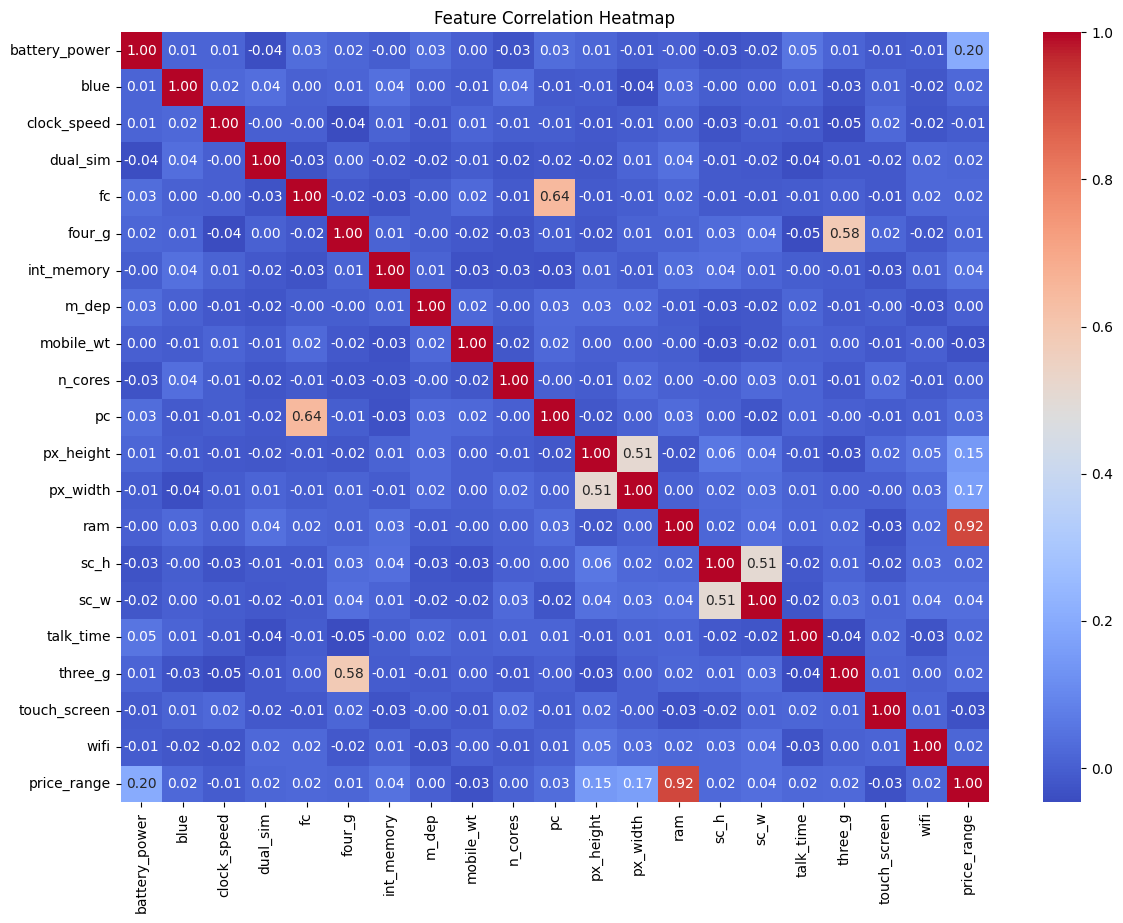

In [173]:
plt.figure(figsize=(14,10))

sns.heatmap(
    corr_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Feature Correlation Heatmap")

plt.show()

---

## 4. Data Quality Checks

Verify the completeness and uniqueness of the dataset before any transformations. Check for **missing values** and **duplicate rows** that could introduce noise or bias into the model.

In [174]:
df.isnull().sum()

battery_power    0
blue             0
clock_speed      0
dual_sim         0
fc               0
four_g           0
int_memory       0
m_dep            0
mobile_wt        0
n_cores          0
pc               0
px_height        0
px_width         0
ram              0
sc_h             0
sc_w             0
talk_time        0
three_g          0
touch_screen     0
wifi             0
price_range      0
dtype: int64

In [175]:
df.duplicated().sum()

np.int64(0)

---

## 5. Outlier Detection & Removal

Visualise the spread of each feature using a **boxplot**, then remove outliers using the **Interquartile Range (IQR) method**.

A row is considered an outlier if any of its feature values fall outside the range:

> Q1 − 1.5 × IQR &nbsp;&nbsp; or &nbsp;&nbsp; Q3 + 1.5 × IQR

The cleaned dataset is stored in `df_clean` for reference. The original `df` continues downstream.

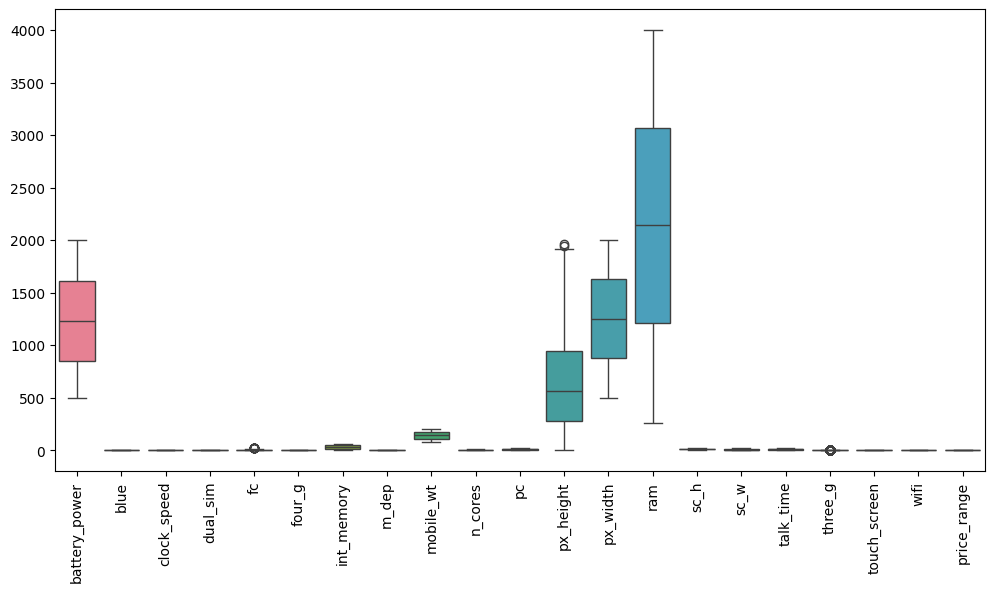

In [176]:
plt.figure(figsize=(12,6))
sns.boxplot(data=df)
plt.xticks(rotation=90)
plt.show()

In [177]:
Q1 = df.quantile(0.25)
Q3 = df.quantile(0.75)

IQR = Q3 - Q1

df_clean = df[~((df < (Q1 - 1.5 * IQR)) | 
                (df > (Q3 + 1.5 * IQR))).any(axis=1)]

In [178]:
df_clean.shape

(1506, 21)

In [179]:
print(df.shape)
print(df_clean.shape)

(2000, 21)
(1506, 21)


In [180]:
df.columns

Index(['battery_power', 'blue', 'clock_speed', 'dual_sim', 'fc', 'four_g',
       'int_memory', 'm_dep', 'mobile_wt', 'n_cores', 'pc', 'px_height',
       'px_width', 'ram', 'sc_h', 'sc_w', 'talk_time', 'three_g',
       'touch_screen', 'wifi', 'price_range'],
      dtype='str')

In [181]:
df.head()

,battery_power,blue,clock_speed,dual_sim,fc,four_g,int_memory,m_dep,mobile_wt,n_cores,...,px_height,px_width,ram,sc_h,sc_w,talk_time,three_g,touch_screen,wifi,price_range
0,842,0,2.2,0,1,0,7,0.6,188,2,...,20,756,2549,9,7,19,0,0,1,1
1,1021,1,0.5,1,0,1,53,0.7,136,3,...,905,1988,2631,17,3,7,1,1,0,2
2,563,1,0.5,1,2,1,41,0.9,145,5,...,1263,1716,2603,11,2,9,1,1,0,2
3,615,1,2.5,0,0,0,10,0.8,131,6,...,1216,1786,2769,16,8,11,1,0,0,2
4,1821,1,1.2,0,13,1,44,0.6,141,2,...,1208,1212,1411,8,2,15,1,1,0,1


---

## 6. Feature Engineering

Six new composite features are derived from the original columns to reduce dimensionality, capture richer information, and improve model interpretability. After each new feature is created, the source columns are dropped.

| Engineered Feature | Source Columns | Operation |
|---|---|---|
| `resolution` | `px_height`, `px_width` | Multiply |
| `screen_size` | `sc_h`, `sc_w` | Multiply |
| `connectivity_score` | `blue`, `wifi`, `three_g`, `four_g`, `dual_sim` | Sum |
| `camera_total_mp` | `fc`, `pc` | Sum |
| `cpu_power` | `n_cores`, `clock_speed` | Multiply |
| `weight_per_screen` | `mobile_wt`, `m_dep` | Divide |

**Result:** Dataset reduced from 21 → 12 columns (11 features + 1 target).

In [182]:
df["resolution"] = df["px_height"] * df["px_width"]

In [183]:
df.corr()["price_range"].sort_values(ascending=False)

price_range      1.000000
ram              0.917046
battery_power    0.200723
resolution       0.176240
px_width         0.165818
px_height        0.148858
int_memory       0.044435
sc_w             0.038711
pc               0.033599
three_g          0.023611
sc_h             0.022986
fc               0.021998
talk_time        0.021859
blue             0.020573
wifi             0.018785
dual_sim         0.017444
four_g           0.014772
n_cores          0.004399
m_dep            0.000853
clock_speed     -0.006606
mobile_wt       -0.030302
touch_screen    -0.030411
Name: price_range, dtype: float64

In [184]:
df = df.drop(["px_height", "px_width"], axis=1)


In [185]:
df.head()

,battery_power,blue,clock_speed,dual_sim,fc,four_g,int_memory,m_dep,mobile_wt,n_cores,pc,ram,sc_h,sc_w,talk_time,three_g,touch_screen,wifi,price_range,resolution
0,842,0,2.2,0,1,0,7,0.6,188,2,2,2549,9,7,19,0,0,1,1,15120
1,1021,1,0.5,1,0,1,53,0.7,136,3,6,2631,17,3,7,1,1,0,2,1799140
2,563,1,0.5,1,2,1,41,0.9,145,5,6,2603,11,2,9,1,1,0,2,2167308
3,615,1,2.5,0,0,0,10,0.8,131,6,9,2769,16,8,11,1,0,0,2,2171776
4,1821,1,1.2,0,13,1,44,0.6,141,2,14,1411,8,2,15,1,1,0,1,1464096


In [186]:
df["screen_size"] = df["sc_h"] * df["sc_w"]

In [187]:
df = df.drop(["sc_h", "sc_w"], axis=1)

In [188]:
df.head()

,battery_power,blue,clock_speed,dual_sim,fc,four_g,int_memory,m_dep,mobile_wt,n_cores,pc,ram,talk_time,three_g,touch_screen,wifi,price_range,resolution,screen_size
0,842,0,2.2,0,1,0,7,0.6,188,2,2,2549,19,0,0,1,1,15120,63
1,1021,1,0.5,1,0,1,53,0.7,136,3,6,2631,7,1,1,0,2,1799140,51
2,563,1,0.5,1,2,1,41,0.9,145,5,6,2603,9,1,1,0,2,2167308,22
3,615,1,2.5,0,0,0,10,0.8,131,6,9,2769,11,1,0,0,2,2171776,128
4,1821,1,1.2,0,13,1,44,0.6,141,2,14,1411,15,1,1,0,1,1464096,16


In [189]:
df["connectivity_score"] = (
    df["blue"] +
    df["wifi"] +
    df["three_g"] +
    df["four_g"] +
    df["dual_sim"]
)

In [190]:
df.head()

,battery_power,blue,clock_speed,dual_sim,fc,four_g,int_memory,m_dep,mobile_wt,n_cores,pc,ram,talk_time,three_g,touch_screen,wifi,price_range,resolution,screen_size,connectivity_score
0,842,0,2.2,0,1,0,7,0.6,188,2,2,2549,19,0,0,1,1,15120,63,1
1,1021,1,0.5,1,0,1,53,0.7,136,3,6,2631,7,1,1,0,2,1799140,51,4
2,563,1,0.5,1,2,1,41,0.9,145,5,6,2603,9,1,1,0,2,2167308,22,4
3,615,1,2.5,0,0,0,10,0.8,131,6,9,2769,11,1,0,0,2,2171776,128,2
4,1821,1,1.2,0,13,1,44,0.6,141,2,14,1411,15,1,1,0,1,1464096,16,3


In [191]:
df.describe()

,battery_power,blue,clock_speed,dual_sim,fc,four_g,int_memory,m_dep,mobile_wt,n_cores,pc,ram,talk_time,three_g,touch_screen,wifi,price_range,resolution,screen_size,connectivity_score
count,2000.000000,2000.0000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2.000000e+03,2000.000000,2000.000000
mean,1238.518500,0.4950,1.522250,0.509500,4.309500,0.521500,32.046500,0.501750,140.249000,4.520500,9.916500,2124.213000,11.011000,0.761500,0.503000,0.507000,1.500000,9.052601e+05,80.257000,2.794500
std,439.418206,0.5001,0.816004,0.500035,4.341444,0.499662,18.145715,0.288416,35.399655,2.287837,6.064315,1084.732044,5.463955,0.426273,0.500116,0.500076,1.118314,8.297625e+05,76.824156,1.196238
min,501.000000,0.0000,0.500000,0.000000,0.000000,0.000000,2.000000,0.100000,80.000000,1.000000,0.000000,256.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000e+00,0.000000,0.000000
25%,851.750000,0.0000,0.700000,0.000000,1.000000,0.000000,16.000000,0.200000,109.000000,3.000000,5.000000,1207.500000,6.000000,1.000000,0.000000,0.000000,0.750000,2.632005e+05,19.000000,2.000000
50%,1226.000000,0.0000,1.500000,1.000000,3.000000,1.000000,32.000000,0.500000,141.000000,4.000000,10.000000,2146.500000,11.000000,1.000000,1.000000,1.000000,1.500000,6.013590e+05,55.000000,3.000000
75%,1615.250000,1.0000,2.200000,1.000000,7.000000,1.000000,48.000000,0.800000,170.000000,7.000000,15.000000,3064.500000,16.000000,1.000000,1.000000,1.000000,2.250000,1.359027e+06,121.500000,4.000000
max,1998.000000,1.0000,3.000000,1.000000,19.000000,1.000000,64.000000,1.000000,200.000000,8.000000,20.000000,3998.000000,20.000000,1.000000,1.000000,1.000000,3.000000,3.886306e+06,342.000000,5.000000


In [192]:
df.describe().T[['min','max']]

,min,max
battery_power,501.0,1998.0
blue,0.0,1.0
clock_speed,0.5,3.0
dual_sim,0.0,1.0
fc,0.0,19.0
four_g,0.0,1.0
int_memory,2.0,64.0
m_dep,0.1,1.0
mobile_wt,80.0,200.0
n_cores,1.0,8.0


In [193]:
df = df.drop(["blue", "wifi", "three_g", "four_g", "dual_sim"], axis=1)

In [194]:
df.head()

,battery_power,clock_speed,fc,int_memory,m_dep,mobile_wt,n_cores,pc,ram,talk_time,touch_screen,price_range,resolution,screen_size,connectivity_score
0,842,2.2,1,7,0.6,188,2,2,2549,19,0,1,15120,63,1
1,1021,0.5,0,53,0.7,136,3,6,2631,7,1,2,1799140,51,4
2,563,0.5,2,41,0.9,145,5,6,2603,9,1,2,2167308,22,4
3,615,2.5,0,10,0.8,131,6,9,2769,11,0,2,2171776,128,2
4,1821,1.2,13,44,0.6,141,2,14,1411,15,1,1,1464096,16,3


In [195]:
df["camera_total_mp"] = df["fc"] + df["pc"]

In [196]:
df["cpu_power"] = df["n_cores"] * df["clock_speed"]

In [197]:
df["weight_per_screen"] = df["mobile_wt"] / df["m_dep"]

In [198]:
df = df.drop(['fc', 'pc', 'n_cores', 'clock_speed', 'mobile_wt', 'm_dep'], axis=1)

In [199]:
df.head()

,battery_power,int_memory,ram,talk_time,touch_screen,price_range,resolution,screen_size,connectivity_score,camera_total_mp,cpu_power,weight_per_screen
0,842,7,2549,19,0,1,15120,63,1,3,4.4,313.333333
1,1021,53,2631,7,1,2,1799140,51,4,6,1.5,194.285714
2,563,41,2603,9,1,2,2167308,22,4,8,2.5,161.111111
3,615,10,2769,11,0,2,2171776,128,2,9,15.0,163.750000
4,1821,44,1411,15,1,1,1464096,16,3,27,2.4,235.000000


In [200]:
df.corr()["price_range"].sort_values(ascending=False)

price_range           1.000000
ram                   0.917046
battery_power         0.200723
resolution            0.176240
int_memory            0.044435
screen_size           0.041248
connectivity_score    0.038329
camera_total_mp       0.031621
talk_time             0.021859
weight_per_screen     0.003327
cpu_power            -0.008290
touch_screen         -0.030411
Name: price_range, dtype: float64

---

## 7. Feature–Target Split

Separate the dataset into the **feature matrix** `X` (all columns except the target) and the **target vector** `y` (`price_range`).

In [201]:
X = df.drop("price_range", axis=1)
y = df["price_range"]

---

## 8. Train–Test Split

Split the data into **training (80%)** and **validation (20%)** sets. `random_state=42` ensures reproducibility.

| Split | Proportion | Rows |
|-------|-----------|------|
| Training | 80% | 1,600 |
| Validation | 20% | 400 |

In [202]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

---

## 9. Feature Scaling

Standardise all features using **StandardScaler** so they have zero mean and unit variance:

$$z = \frac{x - \mu}{\sigma}$$

> ⚠️ The scaler is **fitted on the training set only** and then applied to both train and validation sets. This prevents **data leakage** from the validation set into the scaling parameters.

Post-scaling distributions are verified using a histogram grid of all features.

In [203]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

In [204]:
X_train_scaled = scaler.fit_transform(X_train)

In [205]:
X_test_scaled = scaler.transform(X_test)

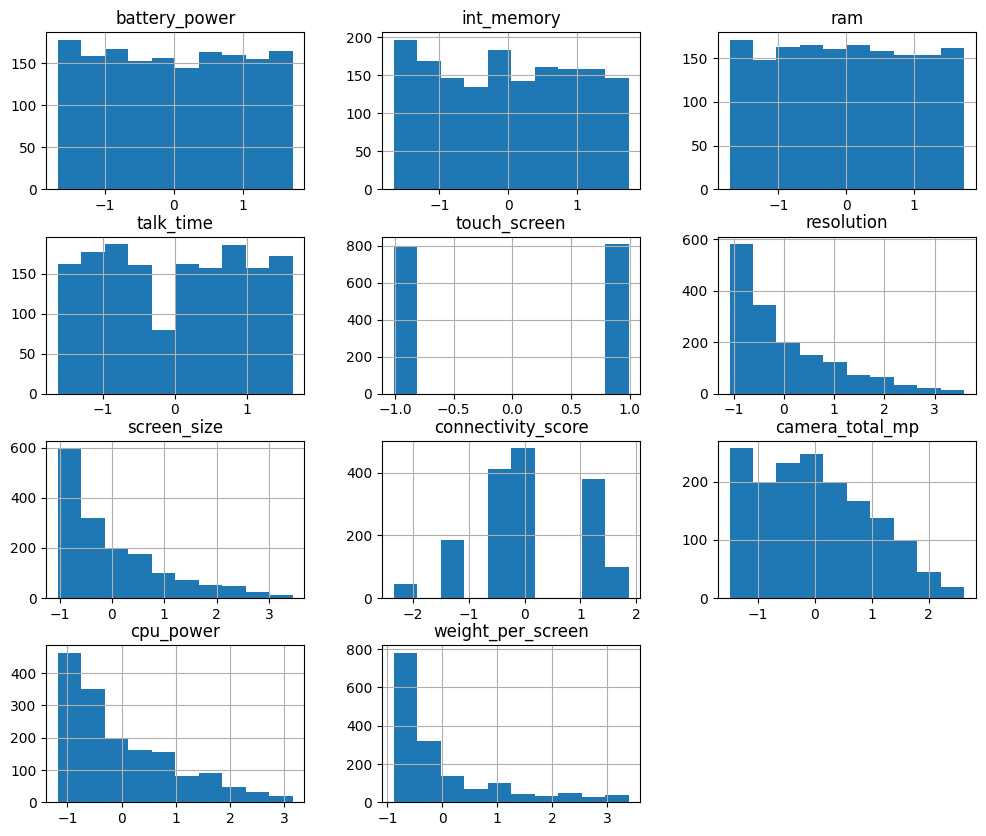

In [206]:
X_train_scaled_df = pd.DataFrame(X_train_scaled, columns=X_train.columns)

X_train_scaled_df.hist(figsize=(12,10))
plt.show()

---

## 10. Model Training

Train a **Logistic Regression** classifier on the scaled training data. Logistic Regression is well-suited for multi-class problems and provides directly interpretable coefficients that can be used for feature importance analysis.

| Parameter | Value |
|-----------|-------|
| Algorithm | `LogisticRegression` |
| Solver | `lbfgs` (default) |
| Regularisation | L2, C = 1.0 (default) |
| Multi-class strategy | `auto` |
| Training samples | 1,600 |

In [207]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression()

model.fit(X_train_scaled, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [208]:
y_pred = model.predict(X_test_scaled)

---

## 11. Model Evaluation

Evaluate model performance on the **held-out validation set** using:
- **Accuracy Score** — overall fraction of correct predictions
- **Confusion Matrix** — breakdown of predictions per class (visualised as a heatmap)
- **Classification Report** — per-class precision, recall, and F1-score (visualised as a heatmap)

> All metrics below are computed against `y_test` (the 20% validation split from `mobile_train.csv`). They do **not** reflect performance on `mobile_test.csv`, which has no ground-truth labels.

In [209]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

Accuracy: 0.935


In [210]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

print(cm)

[[102   3   0   0]
 [  3  85   3   0]
 [  0   6  81   5]
 [  0   0   6 106]]


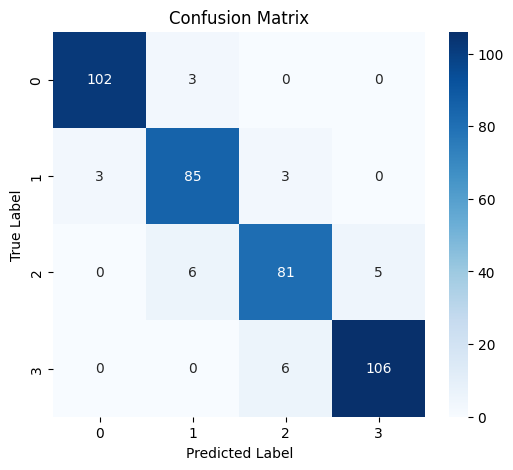

In [211]:
plt.figure(figsize=(6,5))

sns.heatmap(cm, 
            annot=True, 
            fmt='d', 
            cmap='Blues')

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")

plt.show()

In [212]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.97      0.97      0.97       105
           1       0.90      0.93      0.92        91
           2       0.90      0.88      0.89        92
           3       0.95      0.95      0.95       112

    accuracy                           0.94       400
   macro avg       0.93      0.93      0.93       400
weighted avg       0.94      0.94      0.93       400



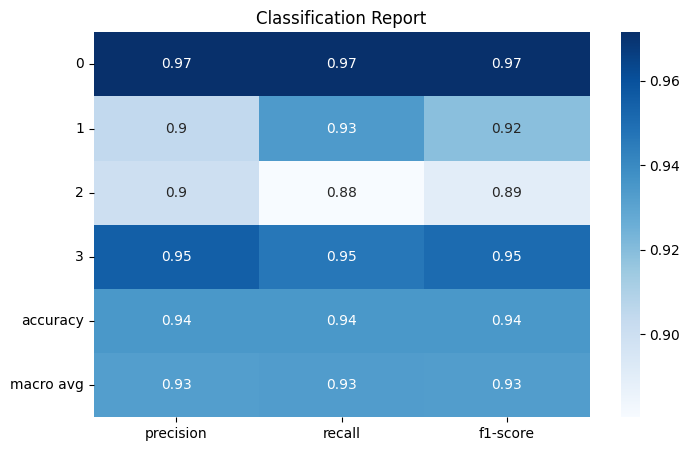

In [213]:
plt.figure(figsize=(8,5))

sns.heatmap(
    df_report.iloc[:-1, :-1], 
    annot=True,
    cmap="Blues"
)

plt.title("Classification Report")
plt.show()

---

## 12. Inference on Unseen Test Data

Apply the trained model to `mobile_test.csv` — an **unlabelled dataset** with no `price_range` column. The exact same preprocessing and feature engineering steps used on the training data are replicated in the same order.

**Key safeguards applied:**
- CSV is reloaded at the top of the cell to ensure **idempotent re-runs** (prevents `KeyError` from columns already being dropped)
- `id` column is dropped conditionally before processing
- `scaler.transform()` is used — **never** `fit_transform()` — to avoid leakage

> Since `mobile_test.csv` has no true labels, a classification report **cannot** be computed for these predictions.

In [214]:
test_df = pd.read_csv("mobile_test.csv")

In [ ]:
test_df = pd.read_csv("mobile_test.csv")

if "id" in test_df.columns:
    test_df = test_df.drop("id", axis=1)


test_df["resolution"] = test_df["px_height"] * test_df["px_width"]
test_df = test_df.drop(["px_height", "px_width"], axis=1)

test_df["screen_size"] = test_df["sc_h"] * test_df["sc_w"]
test_df = test_df.drop(["sc_h", "sc_w"], axis=1)

test_df["connectivity_score"] = (
    test_df["blue"] + test_df["wifi"] + test_df["three_g"] +
    test_df["four_g"] + test_df["dual_sim"]
)
test_df = test_df.drop(["blue", "wifi", "three_g", "four_g", "dual_sim"], axis=1)

test_df["camera_total_mp"] = test_df["fc"] + test_df["pc"]
test_df = test_df.drop(["fc", "pc"], axis=1)

test_df["cpu_power"] = test_df["n_cores"] * test_df["clock_speed"]
test_df = test_df.drop(["n_cores", "clock_speed"], axis=1)

test_df["weight_per_screen"] = test_df["mobile_wt"] / test_df["m_dep"]
test_df = test_df.drop(["mobile_wt", "m_dep"], axis=1)


test_scaled = scaler.transform(test_df)

predictions = model.predict(test_scaled)

In [218]:
print("Accuracy:", accuracy_score(y_test, y_pred))

print(classification_report(y_test, y_pred))

Accuracy: 0.935
              precision    recall  f1-score   support

           0       0.97      0.97      0.97       105
           1       0.90      0.93      0.92        91
           2       0.90      0.88      0.89        92
           3       0.95      0.95      0.95       112

    accuracy                           0.94       400
   macro avg       0.93      0.93      0.93       400
weighted avg       0.94      0.94      0.93       400



---

## 13. Feature Importance

Derive feature importance from the Logistic Regression **coefficients**. For a multi-class model, the absolute coefficient values are averaged across all classes — a higher mean absolute coefficient indicates a stronger influence on the model's decision boundary.

$$\text{importance}_i = \frac{1}{K} \sum_{k=1}^{K} |w_{ki}|$$

Where $K$ = number of classes, $w_{ki}$ = coefficient for feature $i$ in class $k$.

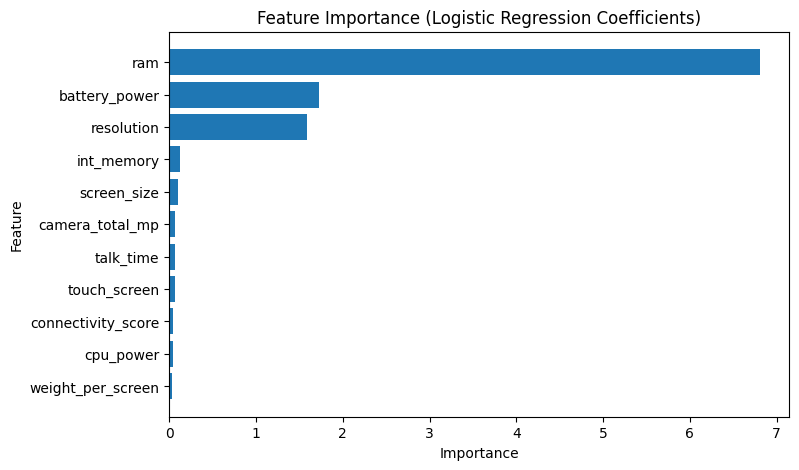

In [219]:
feature_names = X.columns


coefficients = model.coef_


importance = np.mean(np.abs(coefficients), axis=0)


feature_importance = pd.DataFrame({
    "feature": feature_names,
    "importance": importance
}).sort_values(by="importance", ascending=False)


plt.figure(figsize=(8,5))
plt.barh(feature_importance["feature"], feature_importance["importance"])
plt.gca().invert_yaxis()
plt.title("Feature Importance (Logistic Regression Coefficients)")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.show()

---

## 📊 Pipeline Summary & Key Findings

### Results at a Glance

| Metric | Value |
|--------|-------|
| Validation Accuracy | **93.5%** |
| Macro Avg F1-Score | **0.93** |
| Best Performing Class | Class 0 (Low cost) — F1: 0.97 |
| Weakest Performing Class | Class 2 (High cost) — F1: 0.89 |

---

### ⚠️ Model Bias: Heavy Dependence on RAM

The model shows a **significant bias towards RAM** as the dominant predictive feature. From the correlation analysis and feature importance chart, `ram` has by far the highest correlation with `price_range` and the highest coefficient magnitude in the logistic regression model.

**Why this is a concern:**

- The model may effectively be learning a near-linear rule: *"higher RAM → higher price range"*, rather than capturing a holistic picture of device value.
- Features like `battery_power`, `cpu_power`, `camera_total_mp`, and `screen_size` contribute comparatively little to the model's decisions, even though they are real drivers of mobile pricing.
- This means the model could **misclassify** phones with high RAM but low overall specs (e.g., budget phones with large RAM) or phones with low RAM but premium build quality.

**Possible improvements to reduce bias:**

1. **Feature selection** — remove or down-weight RAM, then evaluate if remaining features still produce a competitive model.
2. **Try tree-based models** (Random Forest, XGBoost) — these capture non-linear interactions between features and are less susceptible to a single dominant feature.
3. **Binning or capping RAM** — discretise RAM into buckets to reduce its dominance.
4. **Collect richer features** — brand, OS, display type, and build material are strong real-world price signals not present in this dataset.

---

### Pipeline Steps Completed

| Step | Description |
|------|-------------|
| 1 | Imported libraries |
| 2 | Loaded training data (2,000 rows × 21 cols) |
| 3 | Exploratory Data Analysis — statistics, correlations, heatmap |
| 4 | Data quality checks — 0 nulls, 0 duplicates |
| 5 | Outlier removal via IQR method |
| 6 | Feature engineering — 21 → 12 columns (6 composite features) |
| 7 | Feature–target split |
| 8 | Train–validation split (80/20) |
| 9 | StandardScaler — fit on train only |
| 10 | Logistic Regression — trained on 1,600 samples |
| 11 | Evaluation — 93.5% accuracy on 400-sample validation set |
| 12 | Inference on `mobile_test.csv` (unlabelled) |
| 13 | Feature importance via model coefficients |